# ODI first-innings score prediction

**Goal:** predict the final first-innings score (runs off the bat) of a one-day international from the match
situation at any ball: venue, teams, balls left, wickets left, current score, current run rate and runs in the last 5 overs.

**Data:** ball-by-ball ODI data for the top 10 teams, first innings only, at venues with enough matches. It was built
from the raw ball-by-ball files in an earlier step (see git history).

**Key points of this notebook:**
- Balls from the same innings are almost duplicates of each other. The test set therefore contains **whole innings the model never saw**.
- Models are compared with the run-rate projection that TV commentators use.
- Error is reported by stage of the innings, because predicting from over 10 is much harder than from over 45.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.model_selection import GroupKFold, cross_val_score, train_test_split

import cricket_model as cm

pd.set_option("display.float_format", "{:.3f}".format)
df = cm.load_data()
print(f"{len(df):,} balls | {df['innings_id'].nunique():,} innings | {df['venue'].nunique()} venues")
df.head()

323,930 balls | 1,234 innings | 51 venues


,final_score,venue,batting_team,bowling_team,balls_left,wickets_left,current_score,current_run_rate,last_five,innings_id
0,307,Multan Cricket Stadium,Pakistan,Bangladesh,271,10,13,2.690,13.000,1
1,307,Multan Cricket Stadium,Pakistan,Bangladesh,270,10,13,2.600,13.000,1
2,307,Multan Cricket Stadium,Pakistan,Bangladesh,269,10,13,2.516,13.000,1
3,307,Multan Cricket Stadium,Pakistan,Bangladesh,268,10,13,2.438,13.000,1
4,307,Multan Cricket Stadium,Pakistan,Bangladesh,267,10,13,2.364,13.000,1


## 1. Recovering innings boundaries

The exported table no longer has a `match_id`. Rows are stored innings by innings, so a new innings is detected
when the teams/venue/final score change or the score resets. Check: the last ball of every recovered innings should match its final score.

In [2]:
per_innings = df.groupby("innings_id").agg(last_score=("current_score", "max"), final=("final_score", "first"), balls=("balls_left", "size"))
print("Innings whose highest running score equals the final score:", f"{(per_innings.last_score == per_innings.final).mean():.1%}")
per_innings["balls"].describe()

Innings whose highest running score equals the final score: 100.0%


count   1234.000
mean     262.504
std       40.223
min        2.000
25%      270.000
50%      277.000
75%      280.000
max      297.000
Name: balls, dtype: float64

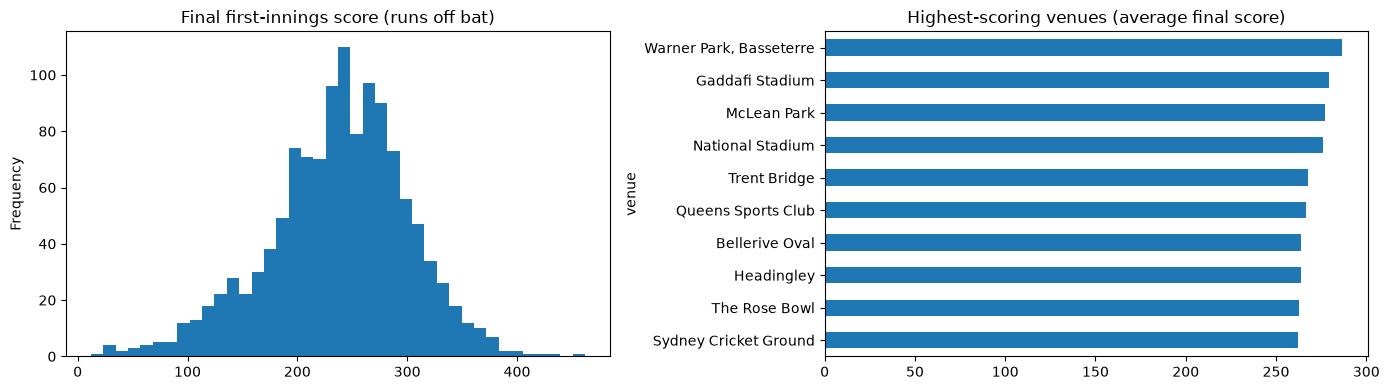

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
per_innings["final"].plot.hist(bins=40, ax=axes[0], title="Final first-innings score (runs off bat)")
venue_avg = df.groupby("venue")["final_score"].mean().sort_values()
venue_avg.tail(10).plot.barh(ax=axes[1], title="Highest-scoring venues (average final score)")
plt.tight_layout()

## 2. Why the split matters

The earlier version of this project used a random row split and reported **R² = 0.96**. With a random split,
the other 250+ balls of the same innings are in the training set, so the model can look up the answer.

In [4]:
tr_idx, te_idx = train_test_split(np.arange(len(df)), test_size=0.2, random_state=42)
random_model = cm.make_xgb_pipeline(n_estimators=100, learning_rate=0.3, max_depth=6, min_child_weight=1)
random_model.fit(df.iloc[tr_idx][cm.FEATURES], df.iloc[tr_idx][cm.TARGET])
print("Random row split:", {k: round(v, 3) for k, v in cm.regression_metrics(
    df.iloc[te_idx][cm.TARGET], random_model.predict(df.iloc[te_idx][cm.FEATURES])).items()})

train, test = cm.innings_split(df)
random_model.fit(train[cm.FEATURES], train[cm.TARGET])
print("Split by innings:", {k: round(v, 3) for k, v in cm.regression_metrics(
    test[cm.TARGET], random_model.predict(test[cm.FEATURES])).items()})

Random row split: {'MAE': 16.209, 'RMSE': 22.398, 'R2': 0.854}


Split by innings: {'MAE': 32.573, 'RMSE': 44.842, 'R2': 0.435}


## 3. Tuning with grouped cross-validation

The same model settings do much worse on unseen innings, which is a sign of overfitting. Shallower, more regularised trees are
compared with 5-fold `GroupKFold` (innings never cross folds), using the training innings only.

In [5]:
grid = {
    "depth 6, lr 0.3, 100 trees (original)": dict(n_estimators=100, learning_rate=0.3, max_depth=6, min_child_weight=1),
    "depth 4, lr 0.05, 300 trees": dict(n_estimators=300, learning_rate=0.05, max_depth=4, min_child_weight=1),
    "depth 3, lr 0.03, 500 trees, min_child_weight 50": dict(n_estimators=500, learning_rate=0.03, max_depth=3, min_child_weight=50),
}
cv = GroupKFold(n_splits=5)
cv_rows = {}
for name, params in grid.items():
    scores = -cross_val_score(cm.make_xgb_pipeline(**params), train[cm.FEATURES], train[cm.TARGET],
                              groups=train["innings_id"], cv=cv, scoring="neg_mean_absolute_error")
    cv_rows[name] = {"CV MAE": scores.mean(), "std": scores.std()}
pd.DataFrame(cv_rows).T

,CV MAE,std
"depth 6, lr 0.3, 100 trees (original)",32.874,1.178
"depth 4, lr 0.05, 300 trees",29.006,0.951
"depth 3, lr 0.03, 500 trees, min_child_weight 50",28.415,1.150


The regularised model (`cm.XGB_PARAMS`) is used from here on.

## 4. Final comparison on held-out innings

In [6]:
metrics, scored = cm.compare_models(df)
metrics

,MAE,RMSE,R2
Run-rate projection (baseline),41.573,54.844,0.155
Ridge regression,30.738,40.989,0.528
XGBoost,29.533,40.484,0.539


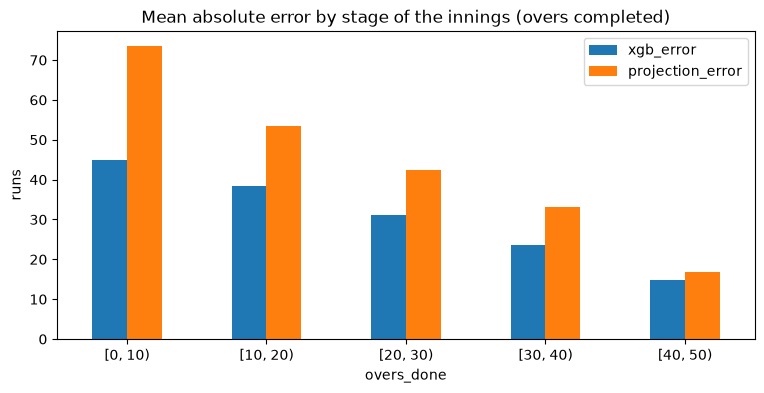

,xgb_error,projection_error
overs_done,,
"[0, 10)",44.909,73.601
"[10, 20)",38.312,53.353
"[20, 30)",31.192,42.432
"[30, 40)",23.506,33.115
"[40, 50)",14.755,16.942


In [7]:
scored = scored.assign(
    overs_done=(cm.BALLS_PER_INNINGS - scored["balls_left"]) // 6,
    xgb_error=(scored["predicted"] - scored[cm.TARGET]).abs(),
    projection_error=np.abs(cm.run_rate_projection(scored) - scored[cm.TARGET]),
)
by_stage = scored.groupby(pd.cut(scored["overs_done"], [0, 10, 20, 30, 40, 50], right=False))[["xgb_error", "projection_error"]].mean()
by_stage.index = by_stage.index.astype(str)
ax = by_stage.plot.bar(figsize=(9, 4), rot=0, title="Mean absolute error by stage of the innings (overs completed)")
ax.set_ylabel("runs"); plt.show()
by_stage

## 5. Which features matter?

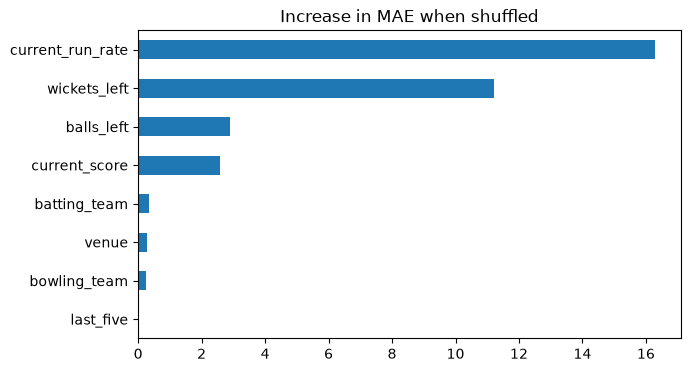

In [8]:
model = cm.make_xgb_pipeline().fit(train[cm.FEATURES], train[cm.TARGET])
sample = test.sample(20_000, random_state=0)
imp = permutation_importance(model, sample[cm.FEATURES], sample[cm.TARGET], scoring="neg_mean_absolute_error", n_repeats=3, random_state=0)
pd.Series(imp.importances_mean, index=cm.FEATURES).sort_values().plot.barh(figsize=(7, 4), title="Increase in MAE when shuffled")
plt.show()

## 6. Conclusions

- The old R² of 0.96 was mostly memorisation. On **unseen innings**, the tuned XGBoost model reaches **MAE ≈ 30 runs (R² ≈ 0.54)**,
  compared with ≈ 42 runs for the run-rate projection.
- The original settings overfit. Shallow trees with larger leaves generalise better.
- Error shrinks steadily as the innings progresses: about 45 runs in the first 10 overs and about 15 runs after 40 overs.
  The model beats the run-rate projection at every stage, and by the widest margin early in the innings.
- **Current run rate** and **wickets in hand** dominate. Venue and teams add small adjustments, and runs in the
  last 5 overs add almost nothing once the run rate is known.

**Next steps:** a time-based split (train on older seasons, test on recent ones) would need the match dates from the raw data.
Adding extras, powerplay phase and team form would probably help early-innings predictions.